# Week 7 Activity: Pandas Practice and Binomial Classification

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code.

In this activity, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' to classify rock vs classical music.

### Filter dataset

First, read the csv into a dataframe. Then, create a new dataframe that only includes rock and pop samples.

In [6]:
import numpy as np
from scipy.io.wavfile import read
from scipy import signal
from librosa import feature, load, frames_to_time
import matplotlib.pyplot as plt
from sklearn import preprocessing
import pandas as pd

df = pd.read_csv('../Datasets/features_30_sec.csv')
columns_to_keep = ['filename', 'label', 'rms_mean', 'spectral_centroid_mean', 'rolloff_mean', 'zero_crossing_rate_mean', 'tempo']
df = df[columns_to_keep]
genres = ['classical', 'rock']
df = df[df['label'].isin(genres)]
df

,filename,label,rms_mean,spectral_centroid_mean,rolloff_mean,zero_crossing_rate_mean,tempo
100,classical.00000.wav,classical,0.036245,1505.166424,2716.306158,0.098223,95.703125
101,classical.00001.wav,classical,0.030625,1360.643672,2387.729130,0.087766,112.347147
102,classical.00002.wav,classical,0.043860,1490.275364,2785.294011,0.090046,99.384014
103,classical.00003.wav,classical,0.029442,1526.629882,2916.000387,0.108946,71.777344
104,classical.00004.wav,classical,0.042316,1705.563259,3174.931743,0.112857,161.499023
...,...,...,...,...,...,...,...
995,rock.00095.wav,rock,0.079486,2008.149458,4253.557033,0.089227,103.359375
996,rock.00096.wav,rock,0.076458,2006.843354,4149.338328,0.097664,117.453835
997,rock.00097.wav,rock,0.081651,2077.526598,4031.405321,0.121823,129.199219
998,rock.00098.wav,rock,0.083860,1398.699344,3015.631004,0.048724,73.828125


### Explore the data

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You should at a minimum create a bar graph and a box plot and compute the correlation between a few features (especially those you plan to select).

Outside of variability in the data, think about why certain features may help us differentiate the two categories based on musical reasoning. 

100     95.703125
101    112.347147
102     99.384014
103     71.777344
104    161.499023
          ...    
995    103.359375
996    117.453835
997    129.199219
998     73.828125
999    123.046875
Name: tempo, Length: 200, dtype: float64


<AxesSubplot: xlabel='label'>

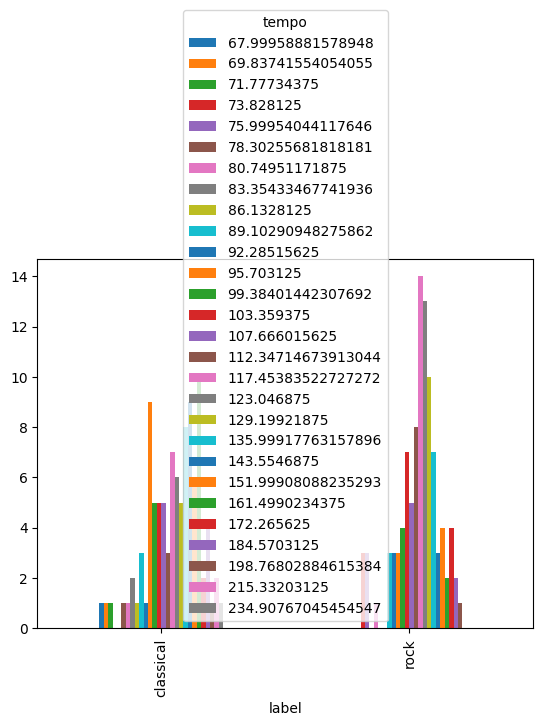

In [ ]:
pd.crosstab(df['label'],df['tempo']).plot.bar()

### Define your feature matrix

Set your x and y based on your selected features and the label outcome.
Note: you will need to convert your 'label' column to 0 and 1. You can do so manually or with .get_dummies

### Scale your feature matrix

Use StandardScaler to scale your feature matrix.

What would happen if you didn't scale?

### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. For this activity, use 30% test size.

### Train the Model

Train the model using logistic regression.

Take a look at your model's coefficients. What do they tell you about each feature's contribution to the model?

### Evaluate

Calculate the confusion matrix (and view as a data frame).

What does the matrix tell you? What error type occurs most often?

Calculate the accuracy, precision, recall, and F1 scores.

What is your models accuracy?

### Extension

Try again using a different feature set or try using the same feature set but with new genres. How does changing features impact your model? How do the same features apply to different genres?

## Extra Pandas practice

You will work with pandas dataframes a lot for Python MIR applications. Here are some more exercises to practice using the Pandas library.

### Practice with pandas Series and Dataframes

#### Making Data & Converting arrays to Series
Let's practice taking some `numpy` arrays and converting them to Series and Dataframe objects.

1. a) Make a numpy array from 2 to 20 with only even numbers.  
b) Make another numpy array from 1 to 19 with only odd numbers.  
c) Wrap each array in a pandas.Series() function to make it a Series object.  

In [ ]:
# Pause and try it

2. Use `np.vstack()` to combine (a) and (b) above into a multidimensional array 

In [ ]:
# stack 2 numpy arrays to 2d array

3. transpose the array (i.e., rotate so that columns become rows)

In [ ]:
# transpose array with the array object's transpose() method 

4. pass your 2d array to a pandas Dataframe function to create a dataframe. Give it a name and save it as a variable.

In [ ]:
# create dataframe

5. Name your columns. Call them "odd" and "even"

In [ ]:
# name the columns with the .columns() method (remember to make it a list!)

#### Read in existing data from a .csv file

Let's practice creating a `pandas` object directly through loading a .csv object. Let's open the file: "weather.csv" from the "Datasets" folder

In [ ]:
# load data with the `pandas.read_csv()` function.
import pandas as pd

df = pd.read_csv('../Datasets/weather.csv')

6. look at the uniqe list of city names from the city column with the `unique()` method

In [ ]:
# how many different cities in the dataframe

7. Count up how many data observations for each city (i.e., how many rows does each unique city name repeat?) Use the `value_counts()` method

In [ ]:
# what are the count values for each city?
df.head()

8. Calculate the mean and standard deviation of the `avg_temp` column using the `.mean()` and `.std()` methods

In [ ]:
# 

#### Plotting

Basic plotting can be done right from your pandas dataframe object if you just want a simple graph:

| Plot Type       | Usage                            | Description / Example Use        |
|------------------|----------------------------------|-----------------------------------|
| **Line**         | `.plot()` or `.plot.line()`     | Default for time series / trends |
| **Bar**          | `.plot.bar()`                   | Vertical bar plot                |
| **Histogram**    | `.plot.hist()`                  | Distribution of values           |
| **Box**          | `.plot.box()`                   | Box-and-whisker plot             |
| **Scatter**      | `.plot.scatter(x='x', y='y')`   | Requires `x` and `y`             |


9. Make a line plot (across all data) with the high temp in red and the low temp in blue

In [ ]:
# First, select only the two columns you care about:

subset = df[['high_temp', 'low_temp']]

# plot them with colors
subset.plot(color=['red', 'blue'])

# if you want to set a title, you have to save the plot as a variable ("ax" is common) and then apply a title, like this:

ax = subset.plot(color=['red', 'blue'])
ax.set_title("High and Low Annual temperatures")


In [ ]:
# Let's instead try a "range" or "lolipop" plot where we plot the *distance* between the low and high temp for each row
# For more sophisticated plots like this we need matplotlib, we can simply pass the series directly to matplot library:
import matplotlib.pyplot as plt

# Plot the points (as before) with red and blue:
x = df.index # these are the row numbers!

# Set the figure size to widen it:
plt.figure(figsize = (14, 6))

plt.scatter(x, df['high_temp'], color='red', label='High Temp')
plt.scatter(x, df['low_temp'], color='blue', label='Low Temp')

# Next draw vertical lines between the points with `plt.vlines(x, y1, y2)`
plt.vlines(x, df['low_temp'], df['high_temp'], color='purple', alpha=0.6)


10. Make a new column of made up data to add to the weather dataframe. Let's call it "predicted_weather"
Using the values from the "events" column, let us randomly select values and put them in our new column. (You will not be making up data but you do need to know how to take a Series or array and "paste" it into an existing dataframe.

In [ ]:
df.events.unique() # note some are lists...

In [ ]:
# save a list variable returning some single events from the "events" column
unique_weather = ["Rain","Fog", "Hail", "Snow", "Thunderstorm"]

In [ ]:
# use numpy's `random.choice()` function to randomly select from your variable. 
import numpy as np
newcoldata = np.random.choice(unique_weather, size = len(df))

# add the newcoldata as a new column of data into your existing dataframe:
df['predicted_weather'] = newcoldata

11. Make a cross-tabulation (confusion matrix) for categorical variables using the `pd.crosstab()` function. Let us look at where our "events" matches our "predicted weather"

In [ ]:
# replace my variables with the appropriate column names to compute the cross tabulation
pd.crosstab(column1, column2)